# Predicting Smartphone Addiction: Initial Data Exploration

This notebook performs an initial exploratory data analysis on the `train.csv` dataset, checking for missing values, basic statistics, and validating a few initial hypotheses.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('../datasets/train.csv')

# Quick preview
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,7.77,1.830000,1.590000,2.110000,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.080000,1.330000,3.030000,8.22,76.0,19.0,9.58,Female,Medium,No,0
2,2,18.0,5.09,2.013339,1.159195,1.917466,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.260000,1.420000,3.360000,8.85,112.0,94.0,8.66,Other,Low,Unknown,1
4,4,26.0,11.20,1.870000,2.810000,1.950000,5.25,150.0,104.0,13.39,Female,Medium,No,1


## Basic Information
Let's look at the shape of the data, column types, and missing values.

In [2]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

print("\n--- Missing Values ---")
print(df.isnull().sum())

Number of Rows: 691369
Number of Columns: 14

--- Missing Values ---
id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
addicted_label             0
dtype: int64


## Summary Statistics
Let's check the mean, min, and max for our numerical columns.

In [3]:
df.describe().loc[['mean', 'min', 'max']].T

,mean,min,max
id,345684.000000,0.00,691368.00
age,26.631501,18.00,35.00
daily_screen_time_hours,7.689204,0.50,15.00
social_media_hours,2.412758,0.00,8.00
gaming_hours,1.422904,0.00,4.00
work_study_hours,2.344051,0.00,6.00
sleep_hours,6.804055,4.50,9.00
notifications_per_day,146.296189,20.00,250.00
app_opens_per_day,102.795922,15.00,180.00
weekend_screen_time,9.496097,0.51,17.56


## Initial Hypotheses

Based on the initial features, we can formulate the following hypotheses to test in future analyses:

1. **Screen Time Hypothesis**: Higher `daily_screen_time_hours` and `weekend_screen_time` correlate positively with the `addicted_label`.
2. **App Usage Hypothesis**: Users with a high number of `app_opens_per_day` and `notifications_per_day` are more likely to have higher `stress_level`s and an `addicted_label`.
3. **Sleep Deprivation Hypothesis**: Higher `addicted_label` instances are associated with fewer `sleep_hours`.
4. **Work/Study Impact Hypothesis**: Users labeled as addicted will have a higher likelihood of reporting 'Yes' in `academic_work_impact`.
5. **Activity Specific Hypothesis**: `social_media_hours` and `gaming_hours` contribute more significantly to addiction than general `work_study_hours`.

In [4]:
# Let's check the distribution of the target variable 'addicted_label'
print("Target Variable Distribution:")
print(df['addicted_label'].value_counts(normalize=True))

Target Variable Distribution:
addicted_label
1    0.709424
0    0.290576
Name: proportion, dtype: float64


## 3. Data Cleaning & Imputation
Based on our strategy, we will impute categorical missing values with 'Unknown' and numerical missing values with the Median.

In [5]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Exclude target and ID from imputation just in case
numerical_cols = [c for c in numerical_cols if c not in ['id', 'addicted_label']]

medians = df[numerical_cols].median()
components = ['social_media_hours', 'gaming_hours', 'work_study_hours']
missing_masks = {col: df[col].isna() for col in components}
missing_daily = df['daily_screen_time_hours'].isna()

# Impute Categorical with 'Unknown'
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# For non-screen time variables, impute with median
for col in numerical_cols:
    if col not in components and col != 'daily_screen_time_hours':
        df[col] = df[col].fillna(medians[col])

import numpy as np
C_orig = df[components].fillna(0).sum(axis=1)
C_imp_sum = sum((missing_masks[col].astype(int) * medians[col]) for col in components)
mask_daily_present = ~missing_daily
violation_mask = mask_daily_present & (C_orig + C_imp_sum > df['daily_screen_time_hours'])
T_avail = np.maximum(0, df['daily_screen_time_hours'] - C_orig)

for col in components:
    df[col] = df[col].fillna(medians[col])
    if missing_masks[col].any():
        prop = np.where(C_imp_sum > 0, medians[col] / C_imp_sum, 0)
        df.loc[violation_mask & missing_masks[col], col] = T_avail[violation_mask] * prop[violation_mask]

df['daily_screen_time_hours'] = df['daily_screen_time_hours'].fillna(medians['daily_screen_time_hours'])
total_components = df[components].sum(axis=1)
mask_missing_daily_violation = missing_daily & (total_components > df['daily_screen_time_hours'])
df.loc[mask_missing_daily_violation, 'daily_screen_time_hours'] = total_components[mask_missing_daily_violation]

print("\n--- Missing Values After Imputation ---")
print(df.isnull().sum())


/tmp/ipykernel_107364/669893751.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns



--- Missing Values After Imputation ---
id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
addicted_label             0
dtype: int64


## 4. Hypothesis Testing
Let's dive deep into testing the hypotheses outlined above.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
sns.set_theme(style="whitegrid")

### Hypothesis 1: Screen Time
Higher `daily_screen_time_hours` and `weekend_screen_time` correlate positively with the `addicted_label`.

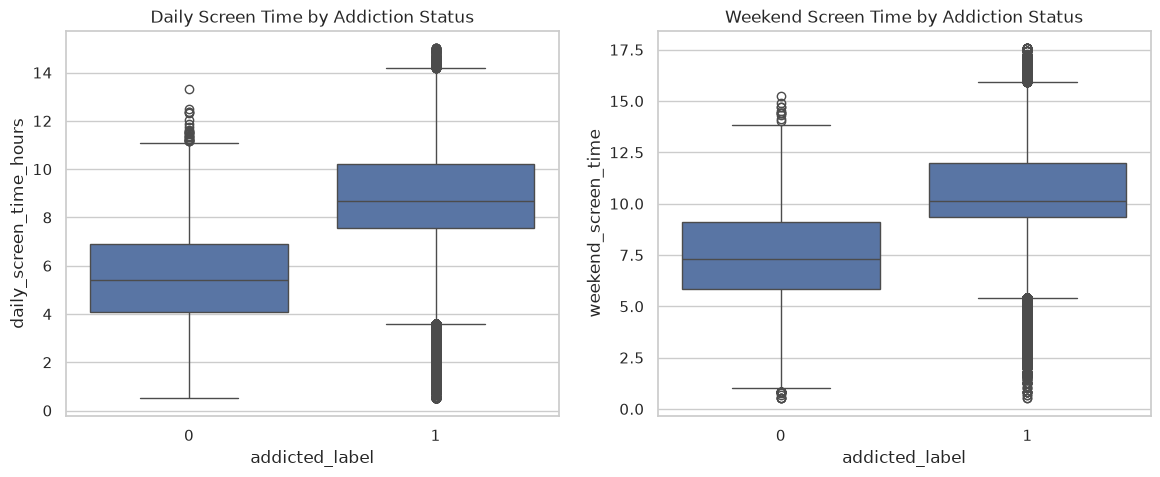

Daily Screen Time MWU p-value: 0.0
Weekend Screen Time MWU p-value: 0.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='addicted_label', y='daily_screen_time_hours', ax=axes[0])
axes[0].set_title('Daily Screen Time by Addiction Status')

sns.boxplot(data=df, x='addicted_label', y='weekend_screen_time', ax=axes[1])
axes[1].set_title('Weekend Screen Time by Addiction Status')

plt.show()

# Statistical Test (Mann-Whitney U)
addicted = df[df['addicted_label'] == 1]
not_addicted = df[df['addicted_label'] == 0]

stat, p = stats.mannwhitneyu(addicted['daily_screen_time_hours'], not_addicted['daily_screen_time_hours'], alternative='greater')
print(f"Daily Screen Time MWU p-value: {p}")

stat, p = stats.mannwhitneyu(addicted['weekend_screen_time'], not_addicted['weekend_screen_time'], alternative='greater')
print(f"Weekend Screen Time MWU p-value: {p}")

### Hypothesis 2: App Usage
Users with a high number of `app_opens_per_day` and `notifications_per_day` are more likely to have higher stress and addiction.

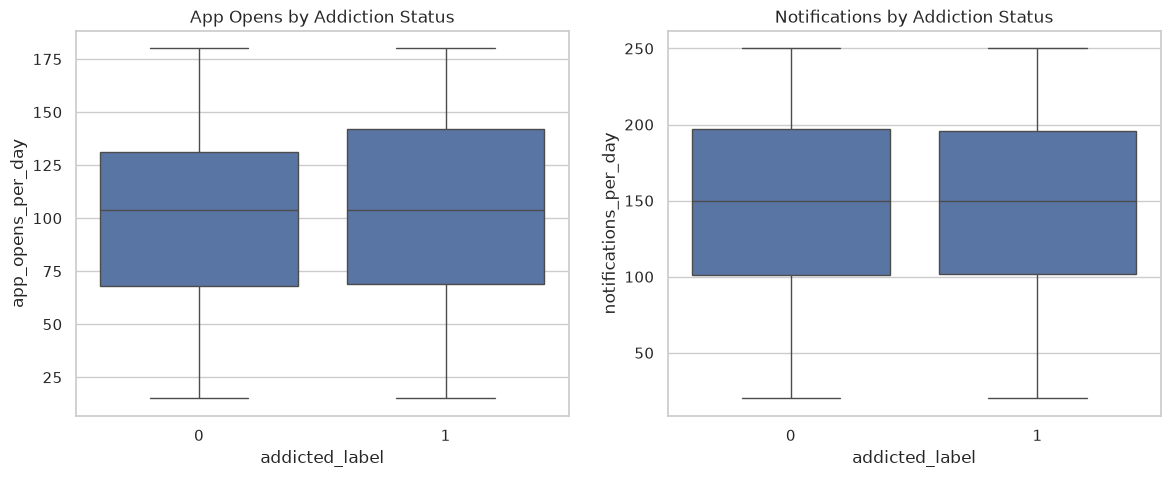

App Opens MWU p-value: 0.0
Notifications MWU p-value: 1.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='addicted_label', y='app_opens_per_day', ax=axes[0])
axes[0].set_title('App Opens by Addiction Status')

sns.boxplot(data=df, x='addicted_label', y='notifications_per_day', ax=axes[1])
axes[1].set_title('Notifications by Addiction Status')

plt.show()

# Test
stat, p = stats.mannwhitneyu(addicted['app_opens_per_day'], not_addicted['app_opens_per_day'], alternative='greater')
print(f"App Opens MWU p-value: {p}")

stat, p = stats.mannwhitneyu(addicted['notifications_per_day'], not_addicted['notifications_per_day'], alternative='greater')
print(f"Notifications MWU p-value: {p}")

### Hypothesis 3: Sleep Deprivation
Higher addicted label instances are associated with fewer `sleep_hours`.

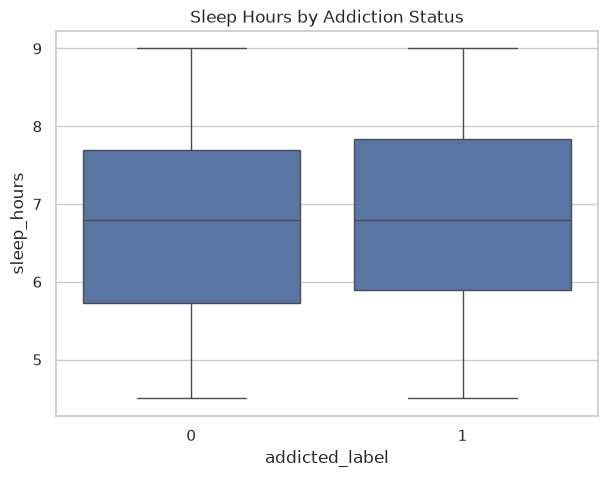

Sleep Hours MWU p-value: 1.0


In [9]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='addicted_label', y='sleep_hours')
plt.title('Sleep Hours by Addiction Status')
plt.show()

# Test (alternative='less' because we expect addicted users to sleep less)
stat, p = stats.mannwhitneyu(addicted['sleep_hours'], not_addicted['sleep_hours'], alternative='less')
print(f"Sleep Hours MWU p-value: {p}")

### Hypothesis 4: Work/Study Impact
Users labeled as addicted will have a higher likelihood of reporting 'Yes' in `academic_work_impact`.

academic_work_impact      No  Unknown     Yes
addicted_label                               
0                      91482    12849   96564
1                     225097    31375  234002


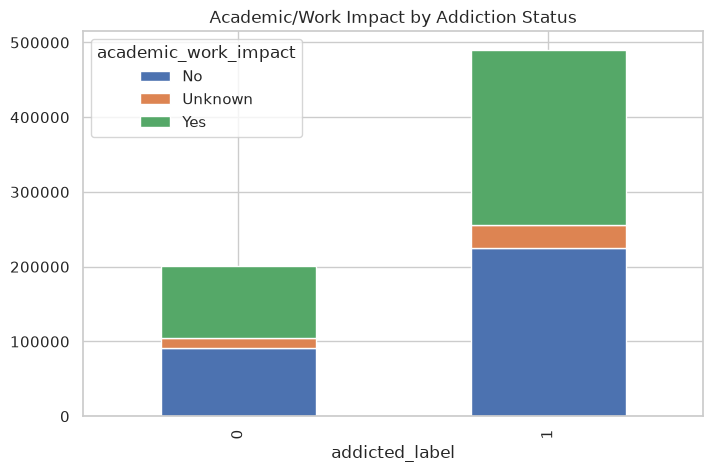

Chi-Square p-value: 0.020574091652763752


In [10]:
# Crosstab
impact_crosstab = pd.crosstab(df['addicted_label'], df['academic_work_impact'])
print(impact_crosstab)

# Plot
impact_crosstab.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Academic/Work Impact by Addiction Status')
plt.show()

# Chi-Square Test
chi2, p, dof, ex = stats.chi2_contingency(impact_crosstab)
print(f"Chi-Square p-value: {p}")

### Hypothesis 5: Activity Specificity
`social_media_hours` and `gaming_hours` contribute more significantly to addiction than `work_study_hours`.

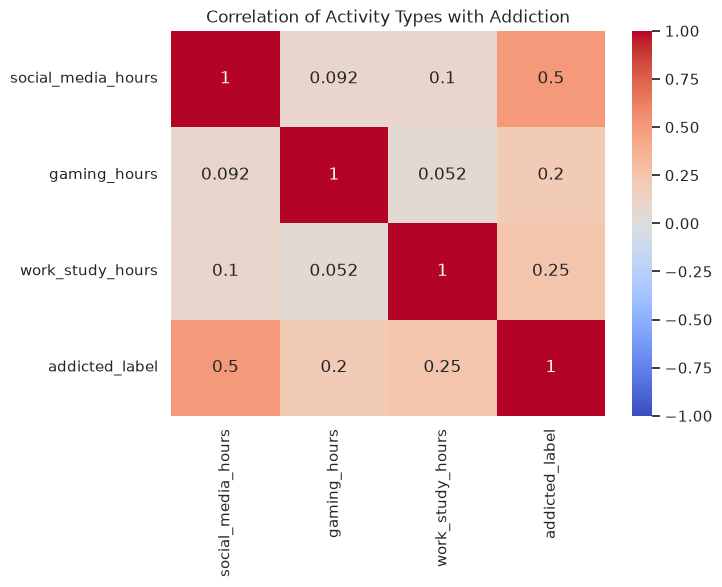

In [11]:
activities = ['social_media_hours', 'gaming_hours', 'work_study_hours', 'addicted_label']
corr = df[activities].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Activity Types with Addiction')
plt.show()